# Rotor-coupled optical model: ¹⁶O + ⁴⁴Ca inelastic scattering

A heavy-ion beam grazing a deformed target can leave it in an excited rotational state.
The standard description couples the elastic channel to the inelastic $2^+$ channels
through the derivative of a deformed Woods–Saxon potential, with an imaginary part
absorbing flux into everything not treated explicitly.

This notebook uses the public preset `lm.models.O16_CA44_ROTOR_MODEL` — a $J = 30$
grazing partial wave with the ⁴⁴Ca $2^+$ state at 1.156 MeV — to show:

1. the ingredients of the coupled optical potential,
2. one direct-path (`linear_solve`) compile for a complex potential on a propagated mesh,
3. the entrance-channel couplings $|S_{0c}(E)|$ and the total absorption.

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import lax as lm

model = lm.models.O16_CA44_ROTOR_MODEL
channels = lm.models.channels_from_rotor_model(model)
for index, channel in enumerate(model.channels):
    print(
        f"channel {index}: {channel.label:>9}   threshold = {channel.threshold} MeV"
    )

channel 0:  0+, L=30   threshold = 0.0 MeV
channel 1:  2+, L=28   threshold = 1.156 MeV
channel 2:  2+, L=30   threshold = 1.156 MeV
channel 3:  2+, L=32   threshold = 1.156 MeV


## The coupled optical potential

`lm.models.rotor_coupled_optical_potential(model, r, i, j)` returns one matrix element
$V_{ij}(r)$: the diagonal carries the complex Woods–Saxon plus the uniform-sphere Coulomb
term, and the off-diagonal carries the deformation coupling
$-\beta R \, \mathrm{d}f/\mathrm{d}r$ weighted by the rotor coupling coefficient. The
preset bundles all the geometry, depths, deformation, and charges, so the notebook never
re-types model constants.

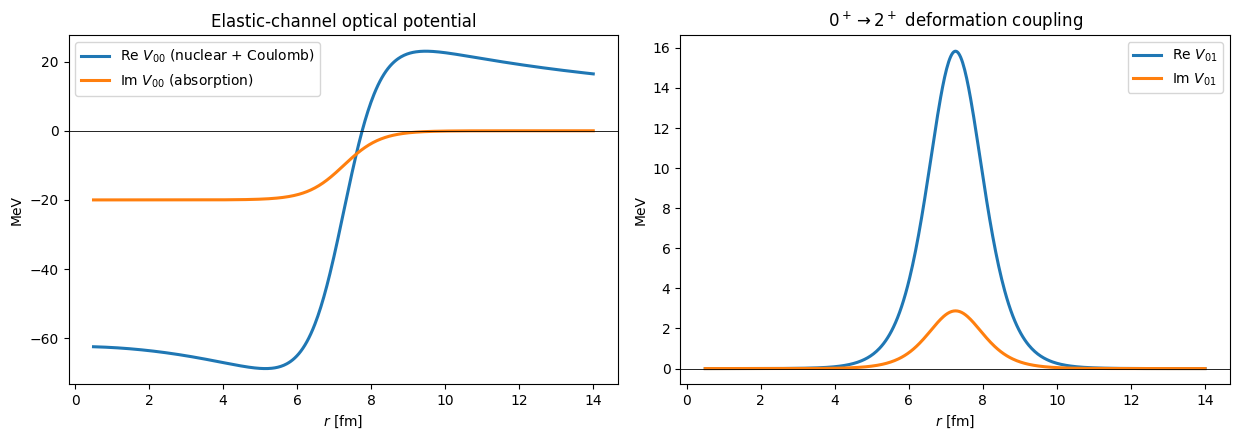

In [2]:
r = np.linspace(0.5, 14.0, 500)
rj = jnp.asarray(r)
v_elastic = np.asarray(lm.models.rotor_coupled_optical_potential(model, rj, 0, 0))
v_coupling = np.asarray(lm.models.rotor_coupled_optical_potential(model, rj, 0, 1))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].plot(r, v_elastic.real, linewidth=2.2, label=r"Re $V_{00}$ (nuclear + Coulomb)")
axes[0].plot(r, v_elastic.imag, linewidth=2.2, label=r"Im $V_{00}$ (absorption)")
axes[0].set_title("Elastic-channel optical potential")
axes[1].plot(r, v_coupling.real, linewidth=2.2, label=r"Re $V_{01}$")
axes[1].plot(r, v_coupling.imag, linewidth=2.2, label=r"Im $V_{01}$")
axes[1].set_title(r"$0^+ \to 2^+$ deformation coupling")
for axis in axes:
    axis.axhline(0.0, color="black", linewidth=0.6)
    axis.set_xlabel(r"$r$ [fm]")
    axis.set_ylabel("MeV")
    axis.legend()
fig.tight_layout()

## Compile the direct solver

The potential is complex, so the scattering problem runs on the **direct path**: per-energy
linear solves (`method="linear_solve"`) on a subinterval-propagated Legendre mesh.
Requesting `"rmatrix_direct"` also binds `solver.smatrix_direct` and
`solver.phases_direct`, which handle the closed-channel decoupling and the Coulomb
matching internally — no per-energy bookkeeping in user code.

In [3]:
energies = jnp.linspace(28.0, 48.0, 40)

solver = lm.compile(
    mesh=lm.MeshSpec("legendre", "x", n=25, scale=14.0, extras={"n_intervals": 4}),
    channels=channels,
    operators=("T+L", "1/r^2"),
    solvers=("rmatrix_direct",),
    energies=energies,
    method="linear_solve",
    V_is_complex=True,
    z1z2=(model.projectile_charge, model.target_charge),
)
interaction = lm.models.interaction_from_rotor_model(model, solver)
smatrices = np.asarray(solver.smatrix_direct(interaction))  # (N_E, N_c, N_c)
print("S-matrix samples:", smatrices.shape)

S-matrix samples: (40, 4, 4)


## Entrance-channel couplings and absorption

The first column of the $S$ matrix answers the practical question: *if the beam enters in
the elastic channel, how much amplitude leaves through each open channel?* Below the
grazing energy the $L = 30$ centrifugal-plus-Coulomb barrier reflects everything
elastically; as the energy rises, flux is shared into the $2^+$ channels and absorbed by
the imaginary potential. The markers are published benchmark values (Descouvemont,
*CPC* **200** (2016)).

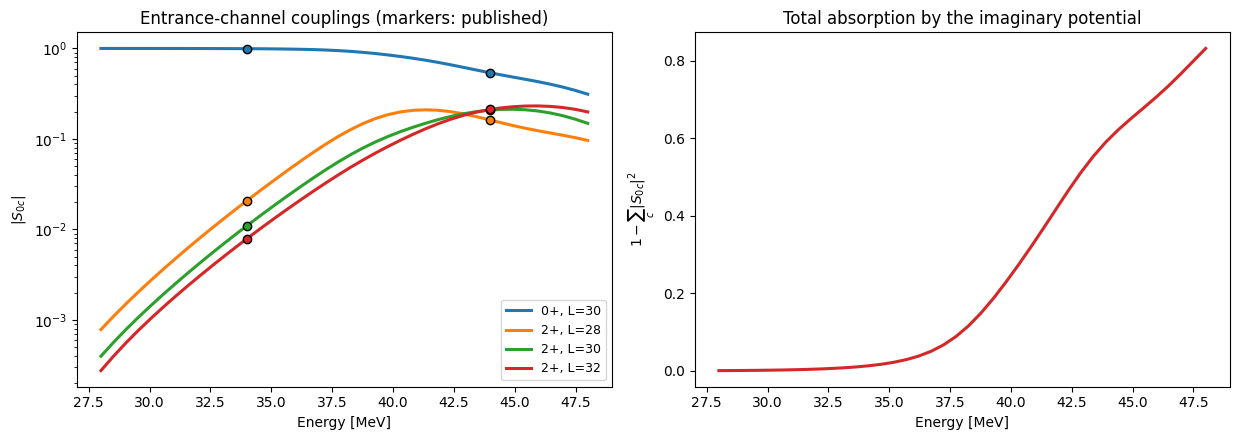

In [4]:
entrance = np.abs(smatrices[:, :, 0])  # (N_E, N_c): |S_c0| = |S_0c|
absorption = 1.0 - np.sum(entrance**2, axis=1)
e_np = np.asarray(energies)

# Published |S_0c| at 34 and 44 MeV (Descouvemont, CPC 200 (2016), a = 14 fm grid).
ref_energies = [34.0, 44.0]
ref_amplitudes = [
    [0.9937, 0.020814, 0.011, 0.0079145],
    [0.53757, 0.16177, 0.20848, 0.21177],
]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for index, channel in enumerate(model.channels):
    line = axes[0].semilogy(e_np, entrance[:, index], linewidth=2.2, label=channel.label)
    axes[0].scatter(
        ref_energies,
        [amplitudes[index] for amplitudes in ref_amplitudes],
        zorder=5,
        color=line[0].get_color(),
        edgecolor="black",
    )
axes[0].set_ylabel(r"$|S_{0c}|$")
axes[0].set_title("Entrance-channel couplings (markers: published)")
axes[0].legend(fontsize=9)

axes[1].plot(e_np, absorption, linewidth=2.2, color="tab:red")
axes[1].set_ylabel(r"$1 - \sum_c |S_{0c}|^2$")
axes[1].set_title("Total absorption by the imaginary potential")
for axis in axes:
    axis.set_xlabel("Energy [MeV]")
fig.tight_layout()

## How to adapt this notebook

`RotorCoupledOpticalModel` is a plain frozen dataclass: copy the preset with
`dataclasses.replace`, change a depth, deformation, or the channel list, and re-run the
same three cells. For scans over many $(J, \pi)$ partial waves, declare them as symmetry
blocks (`lm.compile(blocks=...)`) so one solver batches all of them in a single call.